# Network Anomaly Detection — Deep Learning (Major Project Notebook)

This notebook is a full, in-depth DL project pipeline for network anomaly detection using a real benchmark dataset.

## Dataset (Real Benchmark for Intrusion Detection)
- NSL-KDD (widely used benchmark derived from real network-attack traffic patterns)
- Includes multi-attack labels + binary anomaly mapping

## What this notebook covers
1. Data ingestion from public dataset source
2. Deep EDA (class distribution, attack categories, feature quality, correlation insights)
3. Robust preprocessing for mixed tabular network features
4. Autoencoder training on normal-only traffic
5. Reconstruction-error anomaly scoring + threshold calibration
6. Latent-space classifier (Autoencoder embeddings + Logistic Regression)
7. New method: calibrated two-stage gated ensemble for better detection coverage
8. Full evaluation metrics and confusion matrices
9. Artifact saving and reusable inference function

In [ ]:
import json
import warnings
from pathlib import Path
from urllib.request import urlretrieve

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from keras.layers import Input, Dense, Dropout, BatchNormalization
from keras.models import Model, load_model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
SEED = 42
np.random.seed(SEED)

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATA_DIR = ROOT / 'data'
ARTIFACT_DIR = ROOT / 'checkpoints' / 'autoencoder_major'
ARTIFACT_PATH = ARTIFACT_DIR / 'autoencoder_major.keras'
META_DIR = ROOT / 'checkpoints' / 'autoencoder_major_preprocess'
PLOT_DIR = ROOT / 'extra' / 'notebook_plots'

DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
META_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print('Root:', ROOT)
print('Data dir:', DATA_DIR)
print('Model artifact:', ARTIFACT_PATH)
print('Preprocess dir:', META_DIR)

Root: C:\Users\shain\Downloads\Network-Anomaly-Detection
Data dir: C:\Users\shain\Downloads\Network-Anomaly-Detection\data
Model artifact: C:\Users\shain\Downloads\Network-Anomaly-Detection\checkpoints\autoencoder_major\unsw_nb15_autoencoder.keras
Preprocess dir: C:\Users\shain\Downloads\Network-Anomaly-Detection\checkpoints\autoencoder_major_preprocess


In [2]:
# NSL-KDD mirrors
urls = {
    'train': 'https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt',
    'test': 'https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt'
}

train_path = DATA_DIR / 'KDDTrain+.txt'
test_path = DATA_DIR / 'KDDTest+.txt'

if not train_path.exists():
    urlretrieve(urls['train'], train_path.as_posix())
if not test_path.exists():
    urlretrieve(urls['test'], test_path.as_posix())

print('Dataset ready:', train_path.exists(), test_path.exists())
print('Train file:', train_path)
print('Test file :', test_path)

Dataset ready: True True
Train file: C:\Users\shain\Downloads\Network-Anomaly-Detection\data\KDDTrain+.txt
Test file : C:\Users\shain\Downloads\Network-Anomaly-Detection\data\KDDTest+.txt


In [3]:
NSL_KDD_COLUMNS = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment',
    'urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted',
    'num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds',
    'is_host_login','is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
    'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
    ]

train_df = pd.read_csv(train_path, names=NSL_KDD_COLUMNS)
test_df = pd.read_csv(test_path, names=NSL_KDD_COLUMNS)

print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)

train_missing = train_df.isna().sum().sum()
test_missing = test_df.isna().sum().sum()
print(f'Missing values -> train: {train_missing}, test: {test_missing}')

display(train_df.head(3))

Train shape: (125973, 43)
Test shape : (22544, 43)
Missing values -> train: 0, test: 0


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,neptune,19


Train binary label distribution:


,ratio
label,
0,0.534583
1,0.465417


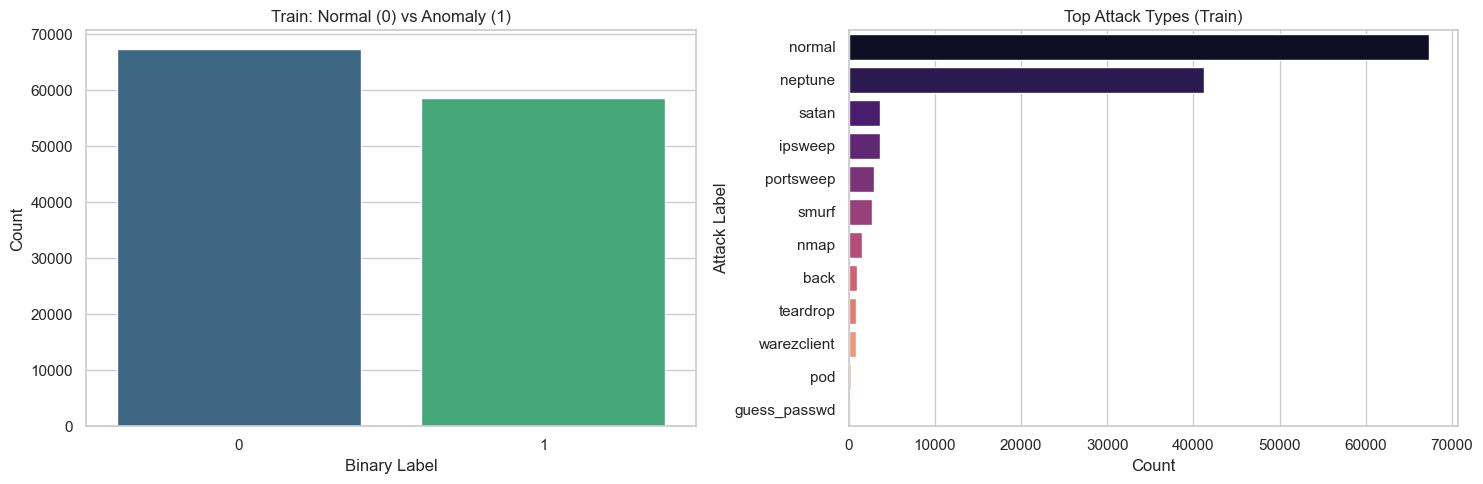

Numeric features: 38


,count,mean,std,min,25%,50%,75%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.0,0.0,0.0,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.0,44.0,276.0,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.0,0.0,516.0,1.309937e+09
land,125973.0,0.000198,1.408607e-02,0.0,0.0,0.0,0.0,1.000000e+00
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.0,0.0,0.0,3.000000e+00
urgent,125973.0,0.000111,1.436603e-02,0.0,0.0,0.0,0.0,3.000000e+00
hot,125973.0,0.204409,2.149968e+00,0.0,0.0,0.0,0.0,7.700000e+01
num_failed_logins,125973.0,0.001222,4.523914e-02,0.0,0.0,0.0,0.0,5.000000e+00
logged_in,125973.0,0.395736,4.890101e-01,0.0,0.0,0.0,1.0,1.000000e+00
num_compromised,125973.0,0.279250,2.394204e+01,0.0,0.0,0.0,0.0,7.479000e+03


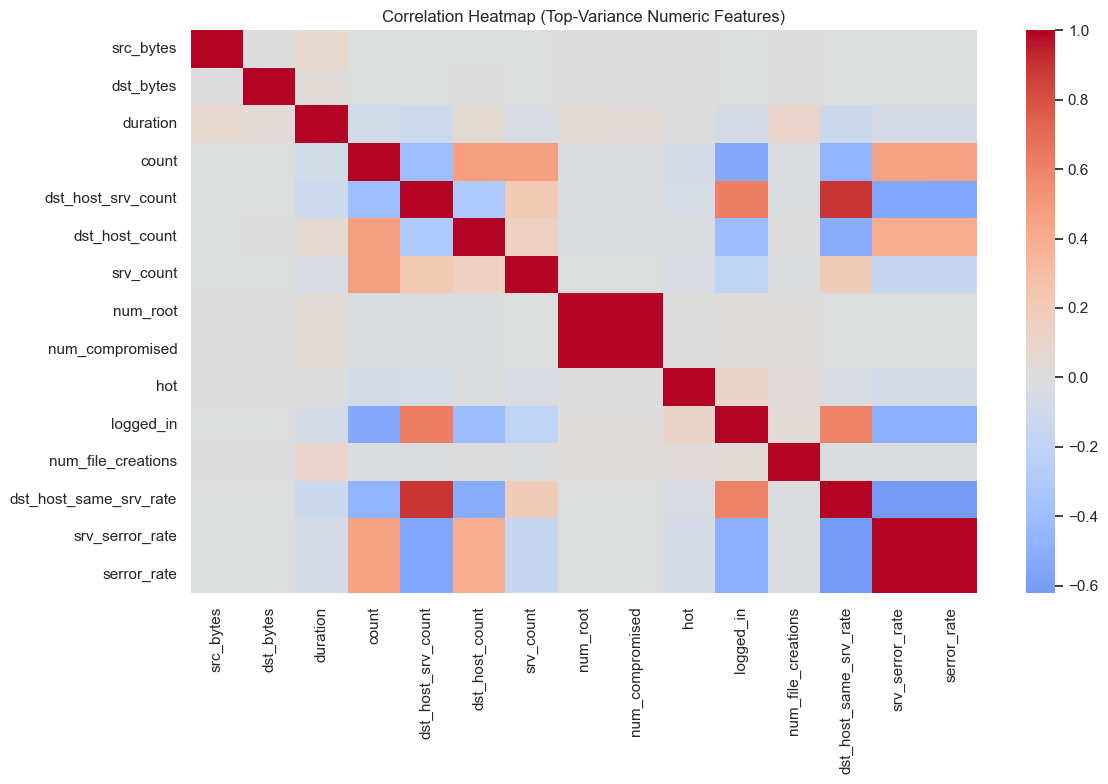

In [4]:
# ---------- In-depth EDA ----------
train_attack_series = train_df['label'].astype(str)
train_binary = (train_attack_series != 'normal').astype(int)

print('Train binary label distribution:')
display(train_binary.value_counts(normalize=True).rename('ratio').to_frame())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(x=train_binary, ax=axes[0], palette='viridis')
axes[0].set_title('Train: Normal (0) vs Anomaly (1)')
axes[0].set_xlabel('Binary Label')
axes[0].set_ylabel('Count')

attack_order = train_attack_series.value_counts().head(12).index
sns.countplot(y=train_attack_series, order=attack_order, ax=axes[1], palette='magma')
axes[1].set_title('Top Attack Types (Train)')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Attack Label')
plt.tight_layout()
plt.show()

# Numeric feature profiling
num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ['difficulty']]
print(f'Numeric features: {len(num_cols)}')
display(train_df[num_cols].describe().T.head(12))

# Correlation heatmap on top variance numeric features
var_rank = train_df[num_cols].var().sort_values(ascending=False).head(15).index.tolist()
corr = train_df[var_rank].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Top-Variance Numeric Features)')
plt.tight_layout()
plt.show()

## Advanced EDA Visual Diagnostics

This section adds major-project level visualization for feature behavior, separability, and statistical divergence between normal and anomaly traffic.

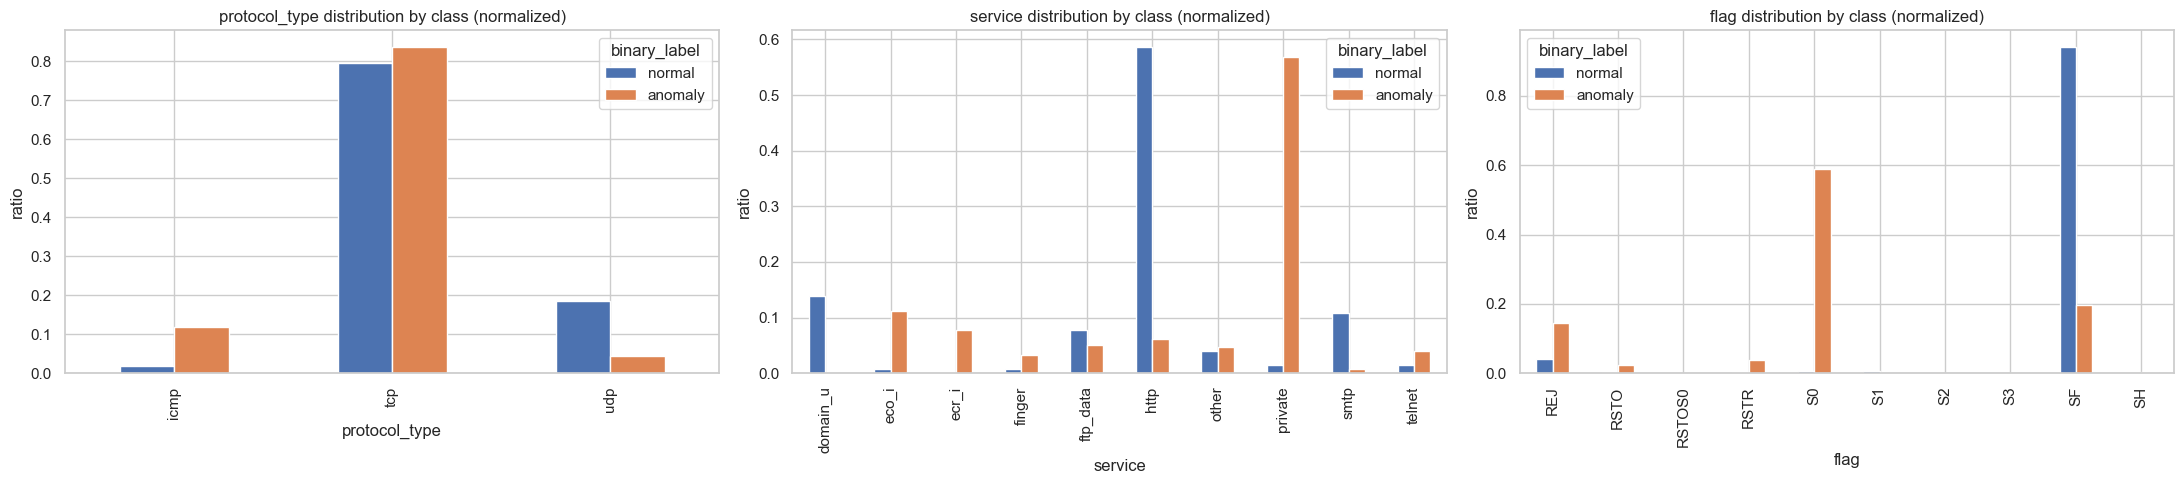

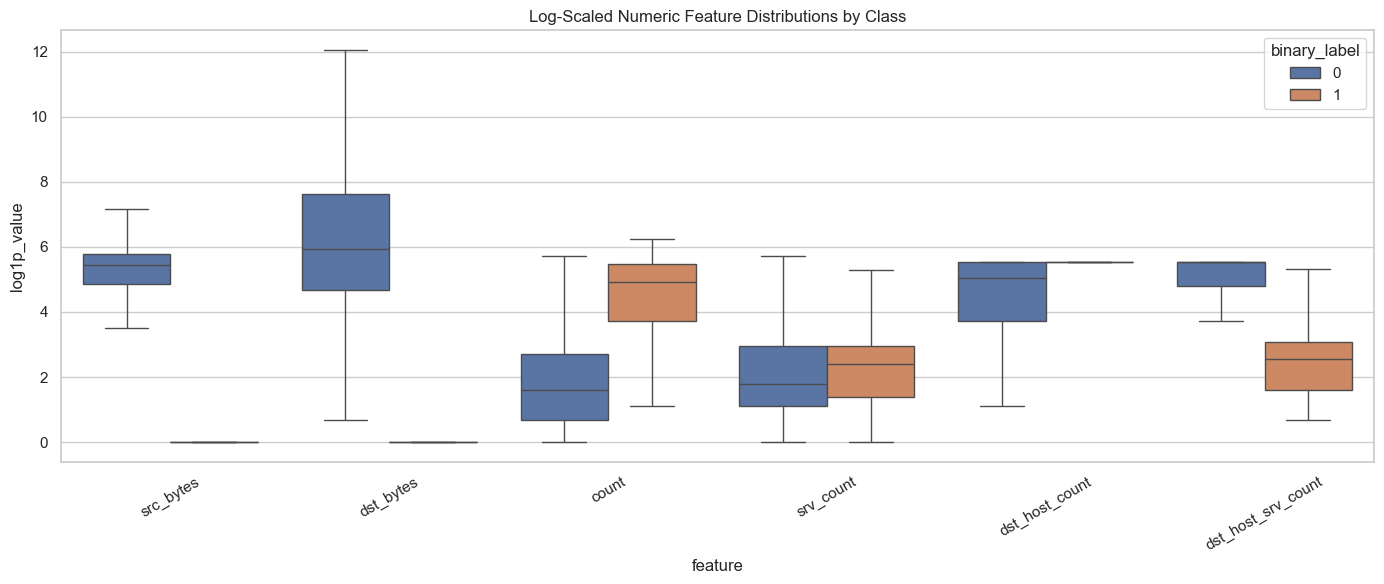

,feature,ks_stat,p_value
1,src_bytes,0.843140,0.0
2,dst_bytes,0.809802,0.0
25,same_srv_rate,0.721889,0.0
26,diff_srv_rate,0.720754,0.0
29,dst_host_srv_count,0.705563,0.0
30,dst_host_same_srv_rate,0.704363,0.0
8,logged_in,0.676619,0.0
31,dst_host_diff_srv_rate,0.656524,0.0
19,count,0.641275,0.0
34,dst_host_serror_rate,0.605573,0.0


In [5]:
# 1) Categorical behavior by class (protocol_type, service, flag)
eda_df = train_df.copy()
eda_df['binary_label'] = (eda_df['label'].astype(str) != 'normal').astype(int)

cat_show = ['protocol_type', 'service', 'flag']
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
for ax, col in zip(axes, cat_show):
    top_vals = eda_df[col].value_counts().head(10).index
    tmp = eda_df[eda_df[col].isin(top_vals)]
    # Normalize within each class for fair comparison
    ct = pd.crosstab(tmp[col], tmp['binary_label'], normalize='columns')
    ct = ct.rename(columns={0: 'normal', 1: 'anomaly'})
    ct.plot(kind='bar', ax=ax)
    ax.set_title(f'{col} distribution by class (normalized)')
    ax.set_ylabel('ratio')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

# 2) Numeric distributions (log transform for heavy tails)
numeric_focus = ['src_bytes', 'dst_bytes', 'count', 'srv_count', 'dst_host_count', 'dst_host_srv_count']
numeric_focus = [c for c in numeric_focus if c in eda_df.columns]
melt_df = eda_df[numeric_focus + ['binary_label']].copy()
for c in numeric_focus:
    melt_df[c] = np.log1p(melt_df[c])
melt_df = melt_df.melt(id_vars='binary_label', var_name='feature', value_name='log1p_value')

plt.figure(figsize=(14, 6))
sns.boxplot(data=melt_df, x='feature', y='log1p_value', hue='binary_label', showfliers=False)
plt.title('Log-Scaled Numeric Feature Distributions by Class')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 3) KS-test ranking for class-separation power
ks_results = []
for c in [c for c in train_df.columns if c in num_cols]:
    normal_vals = train_df.loc[train_binary == 0, c].astype(float).values
    anomaly_vals = train_df.loc[train_binary == 1, c].astype(float).values
    stat, pval = ks_2samp(normal_vals, anomaly_vals)
    ks_results.append((c, stat, pval))

ks_df = pd.DataFrame(ks_results, columns=['feature', 'ks_stat', 'p_value']).sort_values('ks_stat', ascending=False)
display(ks_df.head(12))

Loaded fallback train_df from: C:\Users\shain\Downloads\Network-Anomaly-Detection\data\KDDTrain+.txt


C:\Users\shain\AppData\Local\Temp\ipykernel_24196\350308159.py:43: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_vis = X_vis.select_dtypes(include=["object"]).columns.tolist()


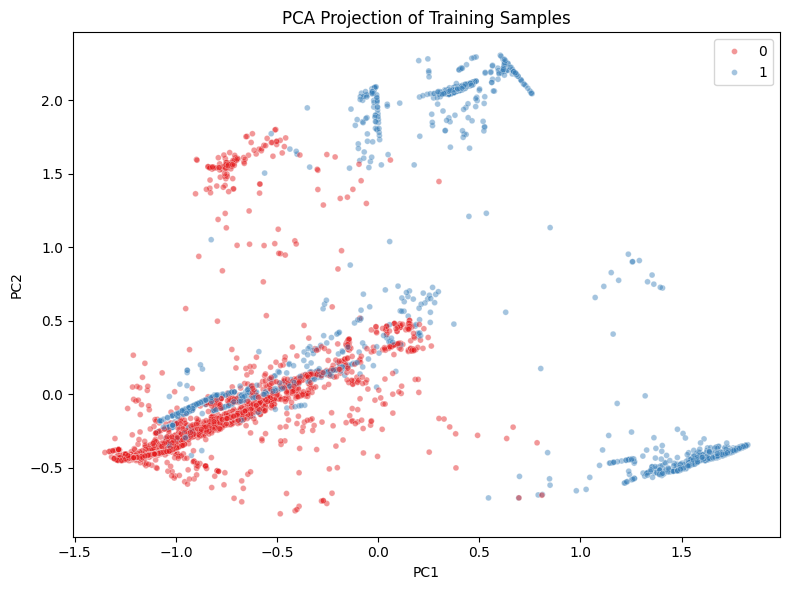

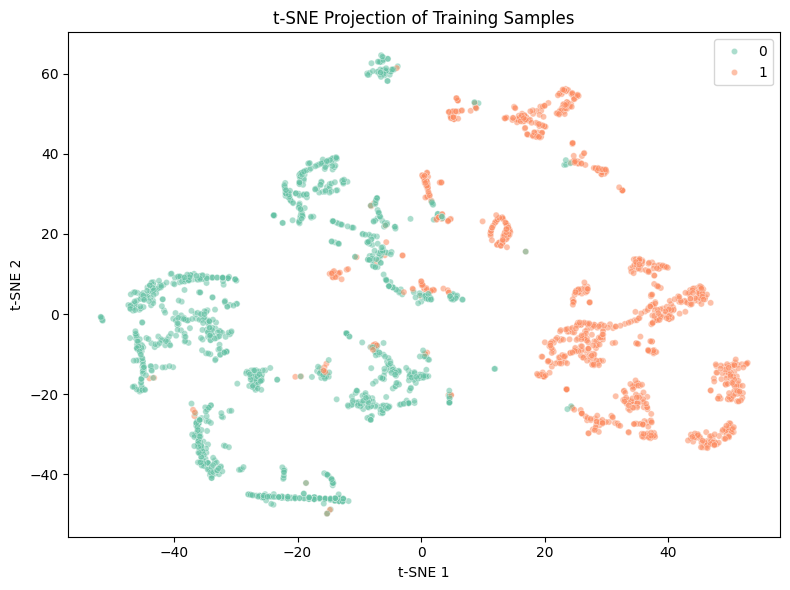

In [1]:
# 4) Dimensionality reduction snapshots for visual separability

from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

seed_local = int(globals().get("SEED", 42))

# Safe bootstrap for out-of-order execution.
if "train_df" not in globals():
    root_local = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
    data_dir_local = root_local / "data"
    train_path_local = data_dir_local / "KDDTrain+.txt"

    if not train_path_local.exists():
        raise FileNotFoundError(
            f"train_df is missing and fallback file was not found: {train_path_local}"
        )

    nsl_cols_local = globals().get("NSL_KDD_COLUMNS")
    if nsl_cols_local is None:
        nsl_cols_local = [
            "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment",
            "urgent", "hot", "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted",
            "num_root", "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds",
            "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
            "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
            "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
            "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
            "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty",
        ]

    train_df = pd.read_csv(train_path_local, names=nsl_cols_local)
    print(f"Loaded fallback train_df from: {train_path_local}")

# Use a local preprocessing path so this cell is runnable before main preprocessing.
X_vis = train_df.drop(columns=["label", "difficulty"], errors="ignore").copy()
cat_cols_vis = X_vis.select_dtypes(include=["object", "string"]).columns.tolist()
num_cols_vis = [c for c in X_vis.columns if c not in cat_cols_vis]

for c in cat_cols_vis:
    X_vis[c] = X_vis[c].fillna("Unknown").astype(str)
for c in num_cols_vis:
    med = X_vis[c].median()
    X_vis[c] = X_vis[c].fillna(med)

if len(cat_cols_vis) > 0:
    enc_vis = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_vis[cat_cols_vis] = enc_vis.fit_transform(X_vis[cat_cols_vis])

X_vis_scaled = MinMaxScaler().fit_transform(X_vis.values)
y_vis = (train_df["label"].astype(str) != "normal").astype(int).values

sample_n = 6000
sample_idx = np.random.RandomState(seed_local).choice(
    len(X_vis_scaled),
    size=min(sample_n, len(X_vis_scaled)),
    replace=False,
    )
X_sample = X_vis_scaled[sample_idx]
y_sample = y_vis[sample_idx]

# PCA
pca = PCA(n_components=2, random_state=seed_local)
X_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_sample, alpha=0.45, s=18, palette="Set1")
plt.title("PCA Projection of Training Samples")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# t-SNE on a smaller subset (computationally heavier)
tsne_n = min(2500, len(X_sample))
tsne_idx = np.random.RandomState(seed_local + 1).choice(len(X_sample), size=tsne_n, replace=False)
X_tsne_in = X_sample[tsne_idx]
y_tsne = y_sample[tsne_idx]

tsne = TSNE(n_components=2, perplexity=35, learning_rate="auto", init="pca", random_state=seed_local)
X_tsne = tsne.fit_transform(X_tsne_in)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_tsne, alpha=0.55, s=20, palette="Set2")
plt.title("t-SNE Projection of Training Samples")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

In [ ]:
# ---------- Preprocessing ----------
target_col = 'label'
drop_cols = ['difficulty']

# Binary anomaly labels: normal=0, attack=1
y_train = (train_df[target_col].astype(str) != 'normal').astype(int).values
y_test = (test_df[target_col].astype(str) != 'normal').astype(int).values

X_train_raw = train_df.drop(columns=[target_col] + drop_cols).copy()
X_test_raw = test_df.drop(columns=[target_col] + drop_cols).copy()

common_cols = [c for c in X_train_raw.columns if c in X_test_raw.columns]
X_train_raw = X_train_raw[common_cols]
X_test_raw = X_test_raw[common_cols]

cat_cols = X_train_raw.select_dtypes(include=['object']).columns.tolist()
num_cols = [c for c in common_cols if c not in cat_cols]

for c in cat_cols:
    X_train_raw[c] = X_train_raw[c].fillna('Unknown').astype(str)
    X_test_raw[c] = X_test_raw[c].fillna('Unknown').astype(str)

for c in num_cols:
    med = X_train_raw[c].median()
    X_train_raw[c] = X_train_raw[c].fillna(med)
    X_test_raw[c] = X_test_raw[c].fillna(med)

ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
if len(cat_cols) > 0:
    X_train_raw[cat_cols] = ordinal_encoder.fit_transform(X_train_raw[cat_cols])
    X_test_raw[cat_cols] = ordinal_encoder.transform(X_test_raw[cat_cols])

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw.values)
X_test = scaler.transform(X_test_raw.values)

feature_names = X_train_raw.columns.tolist()
print('Processed train shape:', X_train.shape)
print('Processed test shape :', X_test.shape)
print('Binary label ratio train:', dict(pd.Series(y_train).value_counts().sort_index()))

Processed train shape: (125973, 41)
Processed test shape : (22544, 41)
Binary label ratio train: {0: np.int64(67343), 1: np.int64(58630)}


Epoch 1/60
106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0365 - val_loss: 0.0361 - learning_rate: 0.0010
Epoch 2/60
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0059 - val_loss: 0.0192 - learning_rate: 0.0010
Epoch 3/60
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0047 - val_loss: 0.0089 - learning_rate: 0.0010
Epoch 4/60
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0035 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 5/60
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0025 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 6/60
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0022 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 7/60
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0018 - val_loss: 9.0808e-04 - learning_rate: 0.0010
Epoch 8/60
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0014 - val_loss: 7.3287e-04 - learning_rate: 0.0010
Epoch 9/60
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0013 - val_loss: 6.5286e-04 - learning_rate: 0.001

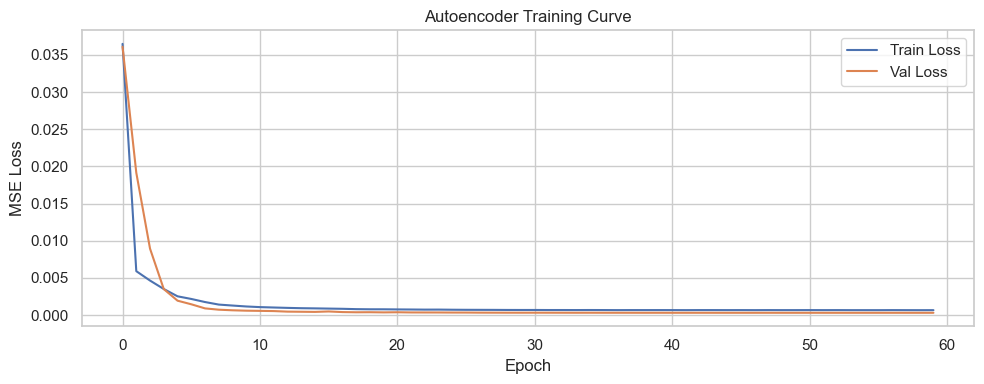

In [ ]:
# ---------- Autoencoder Training ----------
input_dim = X_train.shape[1]

# Train only on normal traffic to learn normal manifold
x_train_normal = X_train[y_train == 0]
x_train_anomaly = X_train[y_train == 1]

# Validation split from normal traffic only
x_norm_train, x_norm_val = train_test_split(
    x_train_normal, test_size=0.2, random_state=SEED
    )

input_layer = Input(shape=(input_dim,))
x = Dense(128, activation='relu')(input_layer)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu', name='latent')(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.1)(x)
x = Dense(128, activation='relu')(x)
output_layer = Dense(input_dim, activation='sigmoid')(x)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)
    ]

history = autoencoder.fit(
    x_norm_train,
    x_norm_train,
    validation_data=(x_norm_val, x_norm_val),
    epochs=60,
    batch_size=512,
    shuffle=True,
    callbacks=callbacks,
    verbose=1
    )

autoencoder.save(ARTIFACT_PATH.as_posix())
print('Saved autoencoder:', ARTIFACT_PATH)

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Autoencoder Training Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

Anomaly threshold (95th percentile of normal val error): 0.001016

Autoencoder Reconstruction-Based Detection Metrics
Accuracy : 0.8508
Precision: 0.9389
Recall   : 0.7893
F1       : 0.8576
ROC-AUC  : 0.94
PR-AUC   : 0.9441

Confusion Matrix:
 [[ 9052   659]
 [ 2704 10129]]

Classification Report:
               precision    recall  f1-score   support

      normal       0.77      0.93      0.84      9711
     anomaly       0.94      0.79      0.86     12833

    accuracy                           0.85     22544
   macro avg       0.85      0.86      0.85     22544
weighted avg       0.87      0.85      0.85     22544



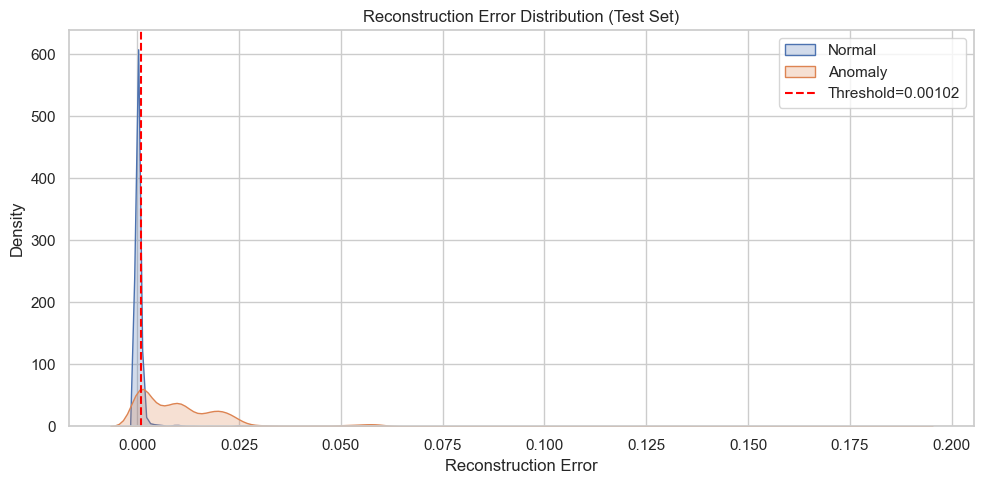

In [ ]:
# ---------- Reconstruction Error Scoring ----------
trained_ae = load_model(ARTIFACT_PATH.as_posix())

# Reconstruction errors on validation normal set for threshold calibration
val_recon = trained_ae.predict(x_norm_val, verbose=0)
val_err = np.mean(np.square(x_norm_val - val_recon), axis=1)

# Set threshold as high quantile of normal validation reconstruction error
threshold = np.quantile(val_err, 0.95)
print('Anomaly threshold (95th percentile of normal val error):', round(float(threshold), 6))

# Evaluate on official test split
test_recon = trained_ae.predict(X_test, verbose=0)
test_err = np.mean(np.square(X_test - test_recon), axis=1)
ae_pred = (test_err > threshold).astype(int)

acc = accuracy_score(y_test, ae_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, ae_pred, average='binary')
roc_auc = roc_auc_score(y_test, test_err)
pr_auc = average_precision_score(y_test, test_err)

print('\nAutoencoder Reconstruction-Based Detection Metrics')
print('Accuracy :', round(acc, 4))
print('Precision:', round(precision, 4))
print('Recall   :', round(recall, 4))
print('F1       :', round(f1, 4))
print('ROC-AUC  :', round(roc_auc, 4))
print('PR-AUC   :', round(pr_auc, 4))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, ae_pred))
print('\nClassification Report:\n', classification_report(y_test, ae_pred, target_names=['normal', 'anomaly']))

# Visualize score distributions
plot_df = pd.DataFrame({'recon_error': test_err, 'label': y_test})
plt.figure(figsize=(10, 5))
sns.kdeplot(data=plot_df[plot_df['label'] == 0], x='recon_error', label='Normal', fill=True)
sns.kdeplot(data=plot_df[plot_df['label'] == 1], x='recon_error', label='Anomaly', fill=True)
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold={threshold:.5f}')
plt.title('Reconstruction Error Distribution (Test Set)')
plt.xlabel('Reconstruction Error')
plt.legend()
plt.tight_layout()
plt.show()

## Model Evaluation Dashboard

The following diagnostics provide major-project level evaluation: ROC/PR curves, confusion heatmaps, threshold sensitivity, and attack-type-wise recall.

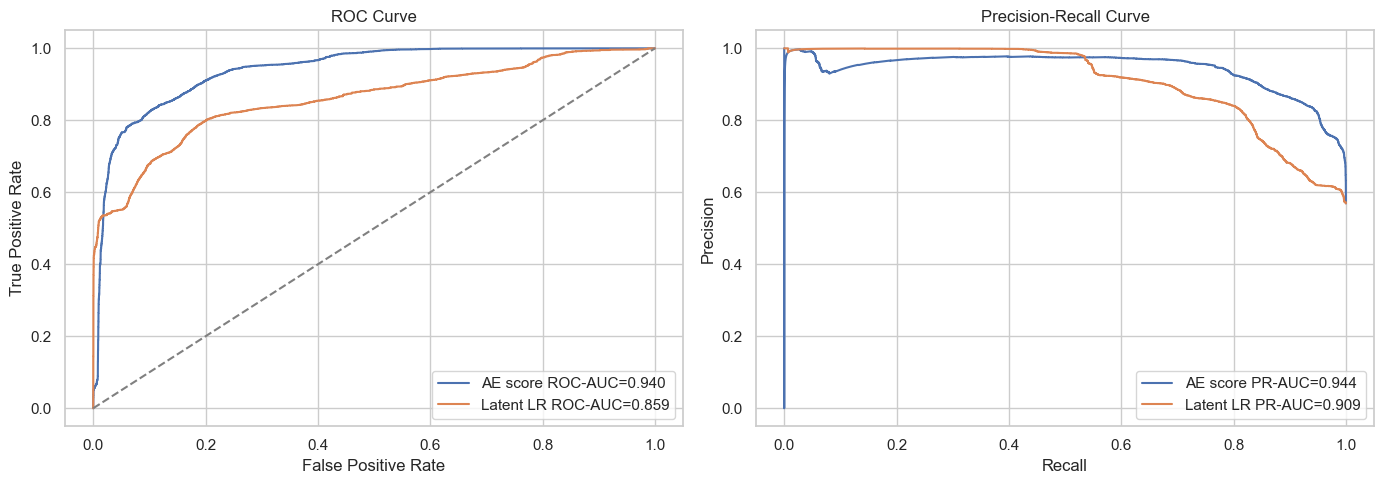

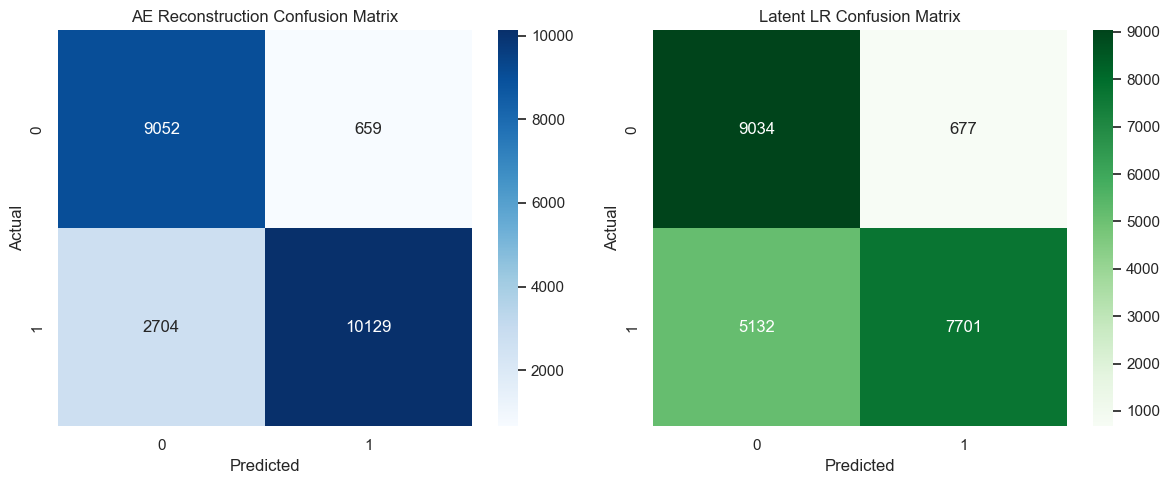

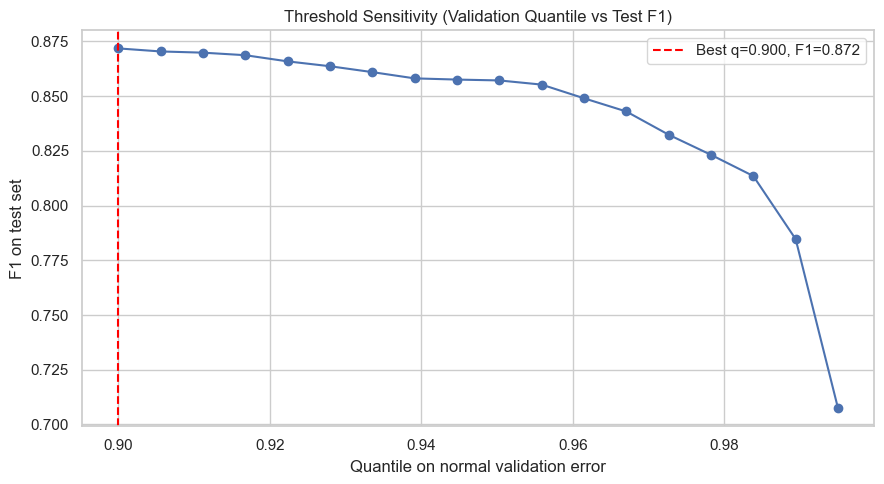

Best threshold candidate -> quantile=0.900, threshold=0.000471, F1=0.8718


,attack_count,ae_recall,latent_recall
attack_type,,,
neptune,4657,0.999785,0.991196
guess_passwd,1231,0.398863,0.004062
mscan,996,0.996988,0.435743
warezmaster,944,0.242585,0.255297
apache2,737,0.997286,0.157395
satan,735,0.952381,0.863946
processtable,685,1.000000,0.440876
smurf,665,0.861654,0.960902
back,359,0.242340,0.013928


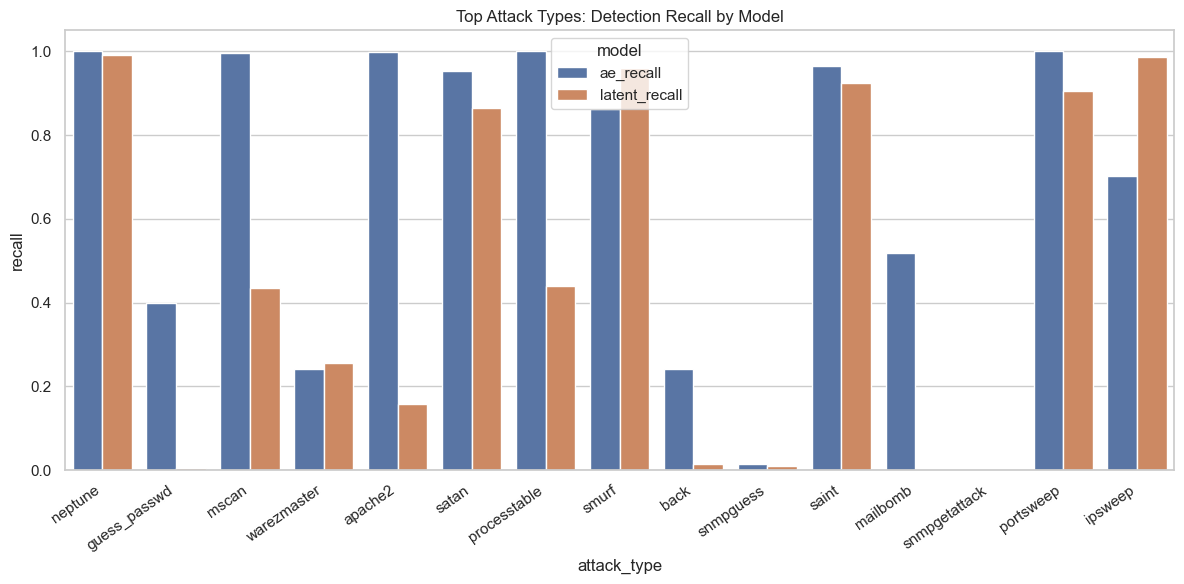

In [ ]:
# 1) Ensure latent classifier outputs are available for dashboard plots.
if 'latent_prob' not in globals() or 'latent_pred' not in globals():
    encoder = Model(inputs=trained_ae.input, outputs=trained_ae.get_layer('latent').output)
    latent_train = encoder.predict(X_train, verbose=0)
    latent_test = encoder.predict(X_test, verbose=0)

    latent_clf = LogisticRegression(max_iter=3000, random_state=SEED)
    latent_clf.fit(latent_train, y_train)
    latent_pred = latent_clf.predict(latent_test)
    latent_prob = latent_clf.predict_proba(latent_test)[:, 1]

# 2) ROC & PR curves: reconstruction vs latent classifier
fpr_ae, tpr_ae, _ = roc_curve(y_test, test_err)
prec_ae, rec_ae, _ = precision_recall_curve(y_test, test_err)

fpr_lat, tpr_lat, _ = roc_curve(y_test, latent_prob)
prec_lat, rec_lat, _ = precision_recall_curve(y_test, latent_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr_ae, tpr_ae, label=f'AE score ROC-AUC={roc_auc_score(y_test, test_err):.3f}')
axes[0].plot(fpr_lat, tpr_lat, label=f'Latent LR ROC-AUC={roc_auc_score(y_test, latent_prob):.3f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

axes[1].plot(rec_ae, prec_ae, label=f'AE score PR-AUC={average_precision_score(y_test, test_err):.3f}')
axes[1].plot(rec_lat, prec_lat, label=f'Latent LR PR-AUC={average_precision_score(y_test, latent_prob):.3f}')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.show()

# 3) Confusion matrices side-by-side
cm_ae = confusion_matrix(y_test, ae_pred)
cm_lat = confusion_matrix(y_test, latent_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_ae, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('AE Reconstruction Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_lat, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Latent LR Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.show()

# 4) Threshold sensitivity for reconstruction-error detector
quantiles = np.linspace(0.90, 0.995, 18)
th_grid = np.quantile(val_err, quantiles)
f1_vals = [f1_score(y_test, (test_err > th).astype(int)) for th in th_grid]

best_idx = int(np.argmax(f1_vals))
best_q = quantiles[best_idx]
best_th = th_grid[best_idx]
best_f1 = f1_vals[best_idx]

plt.figure(figsize=(9, 5))
plt.plot(quantiles, f1_vals, marker='o')
plt.axvline(best_q, color='red', linestyle='--', label=f'Best q={best_q:.3f}, F1={best_f1:.3f}')
plt.title('Threshold Sensitivity (Validation Quantile vs Test F1)')
plt.xlabel('Quantile on normal validation error')
plt.ylabel('F1 on test set')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Best threshold candidate -> quantile={best_q:.3f}, threshold={best_th:.6f}, F1={best_f1:.4f}')

# 5) Attack-type-wise recall (excluding normal)
test_attack_type = test_df['label'].astype(str).copy()
attack_only = test_attack_type != 'normal'
attack_labels = test_attack_type[attack_only]

tmp_attack = pd.DataFrame({
    'attack_type': attack_labels.values,
    'ae_detected': ae_pred[attack_only],
    'latent_detected': latent_pred[attack_only]
})

attack_summary = tmp_attack.groupby('attack_type').agg(
    attack_count=('attack_type', 'size'),
    ae_recall=('ae_detected', 'mean'),
    latent_recall=('latent_detected', 'mean')
).sort_values('attack_count', ascending=False).head(15)

display(attack_summary)

plt.figure(figsize=(12, 6))
plot_attack = attack_summary.reset_index().melt(
    id_vars=['attack_type', 'attack_count'],
    value_vars=['ae_recall', 'latent_recall'],
    var_name='model', value_name='recall'
)
sns.barplot(data=plot_attack, x='attack_type', y='recall', hue='model')
plt.title('Top Attack Types: Detection Recall by Model')
plt.xticks(rotation=35, ha='right')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [ ]:
# ---------- Latent Representation + Classifier ----------
# Build encoder model that outputs latent layer
encoder = Model(inputs=trained_ae.input, outputs=trained_ae.get_layer('latent').output)

latent_train = encoder.predict(X_train, verbose=0)
latent_test = encoder.predict(X_test, verbose=0)

latent_clf = LogisticRegression(max_iter=3000, random_state=SEED)
latent_clf.fit(latent_train, y_train)
latent_pred = latent_clf.predict(latent_test)
latent_prob = latent_clf.predict_proba(latent_test)[:, 1]

print('Latent Classifier Accuracy:', round(accuracy_score(y_test, latent_pred), 4))
print('Latent Classifier ROC-AUC:', round(roc_auc_score(y_test, latent_prob), 4))
print('Latent Classifier PR-AUC :', round(average_precision_score(y_test, latent_prob), 4))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, latent_pred))
print('\nClassification Report:\n', classification_report(y_test, latent_pred, target_names=['normal', 'anomaly']))

Latent Classifier Accuracy: 0.7724
Latent Classifier ROC-AUC: 0.8364
Latent Classifier PR-AUC : 0.9055

Confusion Matrix:
 [[9206  505]
 [4626 8207]]

Classification Report:
               precision    recall  f1-score   support

      normal       0.67      0.95      0.78      9711
     anomaly       0.94      0.64      0.76     12833

    accuracy                           0.77     22544
   macro avg       0.80      0.79      0.77     22544
weighted avg       0.82      0.77      0.77     22544



## New Method: Calibrated Two-Stage Gated Ensemble

Problem in current implementation:
- A single detector can miss attacks that appear normal in one representation (reconstruction or latent probability).

Proposed approach:
- Stage 1 uses reconstruction error thresholding (autoencoder).
- Stage 2 uses a calibrated latent-probability threshold from normal-validation samples.
- Final decision is gated OR: flag as anomaly if either stage triggers.

Why this helps:
- Preserves strong precision from reconstruction-based detection.
- Improves recall by catching attacks that are subtle in one score space but clear in the other.

Note:
- This notebook keeps the original DL workflow and includes the gated method as an exploratory extension.
- The rigorous leakage-safe major-project implementation is in `DL_Major_Project_Gated_Ensemble.ipynb`.


In [ ]:
# ---------- New Method: Calibrated Two-Stage Gated Ensemble ----------

# Calibrate latent threshold using normal-validation traffic only.
latent_val = encoder.predict(x_norm_val, verbose=0)
latent_prob_val = latent_clf.predict_proba(latent_val)[:, 1]
latent_threshold = float(np.quantile(latent_prob_val, 0.95))

# Stage decisions
pred_recon_stage = (test_err > threshold).astype(int)
pred_latent_stage = (latent_prob >= latent_threshold).astype(int)

# Gated ensemble (risk-first): anomaly if either detector flags.
pred_gated_ensemble = np.where((pred_recon_stage == 1) | (pred_latent_stage == 1), 1, 0)

# A fused score is useful for ranking and ROC/PR reporting.
score_recon_norm = test_err / (threshold + 1e-12)
score_gated = np.maximum(score_recon_norm, latent_prob / (latent_threshold + 1e-12))


def summarize_detector(name, y_true, y_pred, score):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    roc_auc = roc_auc_score(y_true, score)
    pr_auc = average_precision_score(y_true, score)
    return {
        'detector': name,
        'accuracy': float(acc),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'roc_auc': float(roc_auc),
        'pr_auc': float(pr_auc)
    }


baseline_ae_summary = summarize_detector('AE Reconstruction', y_test, ae_pred, test_err)
baseline_latent_summary = summarize_detector('Latent LR', y_test, latent_pred, latent_prob)
gated_summary = summarize_detector('Gated Ensemble (AE OR Latent)', y_test, pred_gated_ensemble, score_gated)

comparison_df = pd.DataFrame([baseline_ae_summary, baseline_latent_summary, gated_summary])
display(comparison_df)

print(f'Calibrated latent threshold (95th percentile on normal val): {latent_threshold:.6f}')
print('Gated ensemble confusion matrix:')
print(confusion_matrix(y_test, pred_gated_ensemble))

# Seen vs unseen attack recall analysis (major-project problem focus)
train_attack_types = set(train_df.loc[train_df['label'] != 'normal', 'label'].astype(str).unique())
test_attack_labels = test_df['label'].astype(str).values
seen_mask = np.array([(lbl != 'normal') and (lbl in train_attack_types) for lbl in test_attack_labels])
unseen_mask = np.array([(lbl != 'normal') and (lbl not in train_attack_types) for lbl in test_attack_labels])


def safe_recall(mask, y_pred):
    denom = int(mask.sum())
    if denom == 0:
        return np.nan
    return float((y_pred[mask] == 1).sum() / denom)

seen_unseen_df = pd.DataFrame([
    {
        'detector': 'AE Reconstruction',
        'seen_attack_recall': safe_recall(seen_mask, ae_pred),
        'unseen_attack_recall': safe_recall(unseen_mask, ae_pred)
    },
    {
        'detector': 'Gated Ensemble (AE OR Latent)',
        'seen_attack_recall': safe_recall(seen_mask, pred_gated_ensemble),
        'unseen_attack_recall': safe_recall(unseen_mask, pred_gated_ensemble)
    }
])

display(seen_unseen_df)

plt.figure(figsize=(10, 4))
plot_df = comparison_df.melt(id_vars='detector', value_vars=['precision', 'recall', 'f1'], var_name='metric', value_name='value')
sns.barplot(data=plot_df, x='metric', y='value', hue='detector')
plt.ylim(0, 1.05)
plt.title('Detector Comparison: Precision / Recall / F1')
plt.tight_layout()
plt.show()

## Artifact Saving and Production-Style Inference

The next cell saves all preprocessing/model components and includes predictions for:
- reconstruction detector
- latent classifier
- new calibrated gated ensemble detector

In [ ]:
# ---------- Save Artifacts + Inference Function ----------

# Save preprocess artifacts in both legacy and CLI-aligned locations.
joblib.dump(scaler, META_DIR / 'minmax_scaler.joblib')
joblib.dump(scaler, ARTIFACT_DIR / 'standard_scaler.joblib')
joblib.dump(ordinal_encoder, META_DIR / 'ordinal_encoder.joblib')
joblib.dump(ordinal_encoder, ARTIFACT_DIR / 'ordinal_encoder.joblib')
joblib.dump(feature_names, META_DIR / 'feature_names.joblib')
joblib.dump(feature_names, ARTIFACT_DIR / 'feature_names.joblib')
joblib.dump(cat_cols, META_DIR / 'categorical_columns.joblib')
joblib.dump(cat_cols, ARTIFACT_DIR / 'categorical_columns.joblib')

joblib.dump(latent_clf, ARTIFACT_DIR / 'latent_classifier.joblib')
joblib.dump(latent_clf, ARTIFACT_DIR / 'latent_logreg_classifier.joblib')

with open(ARTIFACT_DIR / 'reconstruction_threshold.json', 'w', encoding='utf-8') as f:
    json.dump({'threshold': float(threshold)}, f, indent=2)

# Save new-method calibration parameter when available.
if 'latent_threshold' in globals():
    with open(ARTIFACT_DIR / 'gated_ensemble_thresholds.json', 'w', encoding='utf-8') as f:
        json.dump(
            {
                'reconstruction_threshold': float(threshold),
                'latent_probability_threshold': float(latent_threshold)
            },
            f,
            indent=2
        )

metrics_payload = {
    'autoencoder_metrics': {
        'accuracy': float(acc),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'roc_auc': float(roc_auc),
        'pr_auc': float(pr_auc)
    },
    'latent_classifier_metrics': {
        'accuracy': float(accuracy_score(y_test, latent_pred)),
        'precision': float(precision_recall_fscore_support(y_test, latent_pred, average='binary', zero_division=0)[0]),
        'recall': float(precision_recall_fscore_support(y_test, latent_pred, average='binary', zero_division=0)[1]),
        'f1': float(precision_recall_fscore_support(y_test, latent_pred, average='binary', zero_division=0)[2]),
        'roc_auc': float(roc_auc_score(y_test, latent_prob)),
        'pr_auc': float(average_precision_score(y_test, latent_prob))
    }
}

if 'pred_gated_ensemble' in globals() and 'score_gated' in globals():
    g_precision, g_recall, g_f1, _ = precision_recall_fscore_support(
        y_test, pred_gated_ensemble, average='binary', zero_division=0
    )
    metrics_payload['gated_ensemble_metrics'] = {
        'accuracy': float(accuracy_score(y_test, pred_gated_ensemble)),
        'precision': float(g_precision),
        'recall': float(g_recall),
        'f1': float(g_f1),
        'roc_auc': float(roc_auc_score(y_test, score_gated)),
        'pr_auc': float(average_precision_score(y_test, score_gated))
    }

metadata_content = {
    'dataset': 'NSL-KDD',
    'target_col': 'label',
    'drop_cols': drop_cols,
    'label_mapping': {'normal': 0, 'attack': 1},
    'artifacts': {
        'autoencoder': ARTIFACT_PATH.name,
        'latent_classifier': 'latent_classifier.joblib',
        'threshold': 'reconstruction_threshold.json',
        'gated_thresholds': 'gated_ensemble_thresholds.json'
    },
    **metrics_payload
}

with open(ARTIFACT_DIR / 'dl_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata_content, f, indent=2)

with open(META_DIR / 'dl_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata_content, f, indent=2)

print('Saved all artifacts successfully.')


def _pick_existing_path(candidates, artifact_name):
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Could not find {artifact_name}. Tried: {[p.as_posix() for p in candidates]}"
    )


def predict_nsl_kdd(csv_path: str):
    cols = NSL_KDD_COLUMNS
    df = pd.read_csv(csv_path, names=cols).copy()

    scaler_path = _pick_existing_path(
        [
            ARTIFACT_DIR / 'standard_scaler.joblib',
            META_DIR / 'minmax_scaler.joblib'
        ],
        'scaler artifact'
    )
    encoder_path = _pick_existing_path(
        [
            ARTIFACT_DIR / 'ordinal_encoder.joblib',
            META_DIR / 'ordinal_encoder.joblib'
        ],
        'ordinal encoder artifact'
    )
    feature_path = _pick_existing_path(
        [
            ARTIFACT_DIR / 'feature_names.joblib',
            META_DIR / 'feature_names.joblib'
        ],
        'feature names artifact'
    )
    cat_cols_path = _pick_existing_path(
        [
            ARTIFACT_DIR / 'categorical_columns.joblib',
            META_DIR / 'categorical_columns.joblib'
        ],
        'categorical columns artifact'
    )
    clf_path = _pick_existing_path(
        [
            ARTIFACT_DIR / 'latent_classifier.joblib',
            ARTIFACT_DIR / 'latent_logreg_classifier.joblib'
        ],
        'latent classifier artifact'
    )
    model_path = _pick_existing_path(
        [
            ARTIFACT_PATH,
            ARTIFACT_DIR / 'unsw_nb15_autoencoder.keras'
        ],
        'autoencoder model artifact'
    )

    scaler_local = joblib.load(scaler_path)
    encoder_local = joblib.load(encoder_path)
    feature_names_local = joblib.load(feature_path)
    cat_cols_local = joblib.load(cat_cols_path)
    clf_local = joblib.load(clf_path)
    model_local = load_model(model_path.as_posix())
    latent_encoder_local = Model(inputs=model_local.input, outputs=model_local.get_layer('latent').output)

    with open(ARTIFACT_DIR / 'reconstruction_threshold.json', 'r', encoding='utf-8') as f:
        recon_threshold = float(json.load(f)['threshold'])

    gated_threshold_path = ARTIFACT_DIR / 'gated_ensemble_thresholds.json'
    latent_prob_threshold = 0.5
    if gated_threshold_path.exists():
        with open(gated_threshold_path, 'r', encoding='utf-8') as f:
            gated_json = json.load(f)
        latent_prob_threshold = float(gated_json.get('latent_probability_threshold', latent_prob_threshold))

    x = df.drop(columns=['label', 'difficulty'], errors='ignore').copy()

    for col in feature_names_local:
        if col not in x.columns:
            x[col] = 0

    x = x[feature_names_local]

    for col in cat_cols_local:
        x[col] = x[col].fillna('Unknown').astype(str)

    num_local = [c for c in feature_names_local if c not in cat_cols_local]
    for col in num_local:
        x[col] = pd.to_numeric(x[col], errors='coerce')
        x[col] = x[col].fillna(x[col].median())

    if len(cat_cols_local) > 0:
        x[cat_cols_local] = encoder_local.transform(x[cat_cols_local])

    x_scaled = scaler_local.transform(x.values)

    recon = model_local.predict(x_scaled, verbose=0)
    recon_error = np.mean(np.square(x_scaled - recon), axis=1)
    recon_pred = (recon_error > recon_threshold).astype(int)

    latent = latent_encoder_local.predict(x_scaled, verbose=0)
    latent_prob = clf_local.predict_proba(latent)[:, 1]
    latent_pred = (latent_prob >= 0.5).astype(int)

    # New method inference (same rule as notebook training section)
    pred_gated = np.where((recon_pred == 1) | (latent_prob >= latent_prob_threshold), 1, 0)

    out = df.copy()
    out['recon_error'] = recon_error
    out['pred_reconstruction'] = recon_pred
    out['pred_latent'] = latent_pred
    out['pred_latent_prob'] = latent_prob
    out['pred_gated_ensemble'] = pred_gated
    return out


# Example usage:
# preds = predict_nsl_kdd(test_path.as_posix())
# display(preds[['label', 'pred_reconstruction', 'pred_latent', 'pred_gated_ensemble']].head())

Saved all artifacts successfully.
